In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr = 'spearman'

data_dir_1 = os.path.join('..', 'data', 'case_study_1_revised')
data_dir_2 = os.path.join('..', 'data', 'case_study_2_revised')
result_dir_1 = os.path.join('..', 'results', 'case_study_1_revised')
result_dir_2 = os.path.join('..', 'results', 'case_study_2_revised')

config_full = pd.read_csv(os.path.join('..', 'data', 'config_all.csv'), sep=";")
config_sample = pd.read_csv(os.path.join('..', 'data', 'case_study_2_revised', 'configs', 'config_1.csv'), sep=";")

corrs_1 = pd.read_csv(os.path.join(data_dir_1, 'correlations.csv'), sep=";")
corrs_2 = pd.read_csv(os.path.join(data_dir_2, 'correlations.csv'), sep=";")

corr_matrix_1 = corrs_1.pivot(index='source', columns='target', values=corr)
corr_matrix_2 = corrs_2.pivot(index='source', columns='target', values=corr)
difference_matrix = corr_matrix_1 - corr_matrix_2

pipeline                                         1.00
preprocessing                                    1.00
motion_correction_realignment                    1.00
motion_correction_realignment/tool               1.00
motion_correction_realignment/tool/spm           1.00
                                                 ... 
signal_modeling/nuisance_regressors/motion       0.75
signal_modeling/nuisance_regressors/motion/6     0.25
signal_modeling/nuisance_regressors/motion/18    0.25
signal_modeling/nuisance_regressors/motion/24    0.25
signal_modeling/nuisance_regressors/comp_cor     0.00
Length: 92, dtype: float64


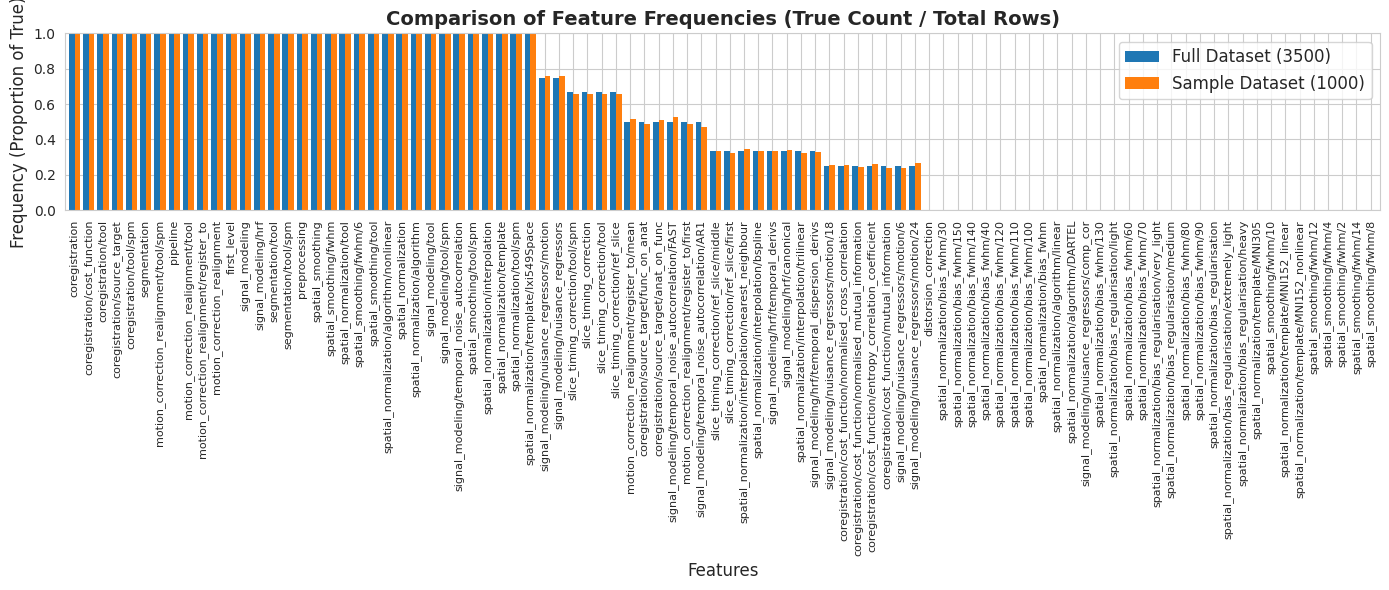

Total Variation Distance (TVD): 0.1352
signal_modeling/temporal_noise_autocorrelation/AR1              0.028
signal_modeling/temporal_noise_autocorrelation/FAST             0.028
signal_modeling/nuisance_regressors/motion/24                   0.015
motion_correction_realignment/register_to/mean                  0.013
motion_correction_realignment/register_to/first                 0.013
signal_modeling/nuisance_regressors/motion/6                    0.012
coregistration/cost_function/mutual_information                 0.012
coregistration/cost_function/entropy_correlation_coefficient    0.012
coregistration/source_target/func_on_anat                       0.011
coregistration/source_target/anat_on_func                       0.011
dtype: float64
Mean Absolute Error (MAE): 0.0029


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Compute Frequencies (Proportion of True over Total Rows) ---
freq_full = config_full.mean()  # .mean() on booleans calculates the ratio of True
print(freq_full)
freq_sample = config_sample.mean()
# print(freq_sample)

# Combine into a single DataFrame for easy plotting
plot_df = pd.DataFrame(
    {"Full Dataset (3500)": freq_full, "Sample Dataset (1000)": freq_sample}
)

# Optional: Sort by the full dataset frequencies in descending order for clarity
plot_df = plot_df.sort_values(by="Full Dataset (3500)", ascending=False)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 6))

plot_df.plot(
    kind="bar",
    ax=ax,
    width=0.8,
    color=["#1f77b4", "#ff7f0e"],
    edgecolor="none",
)

plt.title(
    "Comparison of Feature Frequencies (True Count / Total Rows)",
    fontsize=14,
    weight="bold",
)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Frequency (Proportion of True)", fontsize=12)
plt.ylim(0, 1.0)  # Frequencies range from 0 to 1
plt.xticks(rotation=90, fontsize=8)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

tvd = (freq_full - freq_sample).abs().sum() / 2
print(f"Total Variation Distance (TVD): {tvd:.4f}")
# See which features have the biggest individual discrepancies
diff = (freq_full - freq_sample).abs()
print(diff.sort_values(ascending=False).head(10))

# --- Compute Frequencies (Proportions of True) ---
freq_full = config_full.mean()
freq_sample = config_sample.mean()

# --- Compute Mean Absolute Error (MAE) ---
# This calculates the average absolute difference per feature
mae = (freq_full - freq_sample).abs().mean()

print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Pairwise correlations matrix for both case studies.

/home/ymerel/fmri/sosym_2026/.venv/lib64/python3.13/site-packages/scipy/cluster/hierarchy.py:810: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')
/home/ymerel/fmri/sosym_2026/.venv/lib64/python3.13/site-packages/scipy/cluster/hierarchy.py:810: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  return linkage(y, method='ward', metric='euclidean')


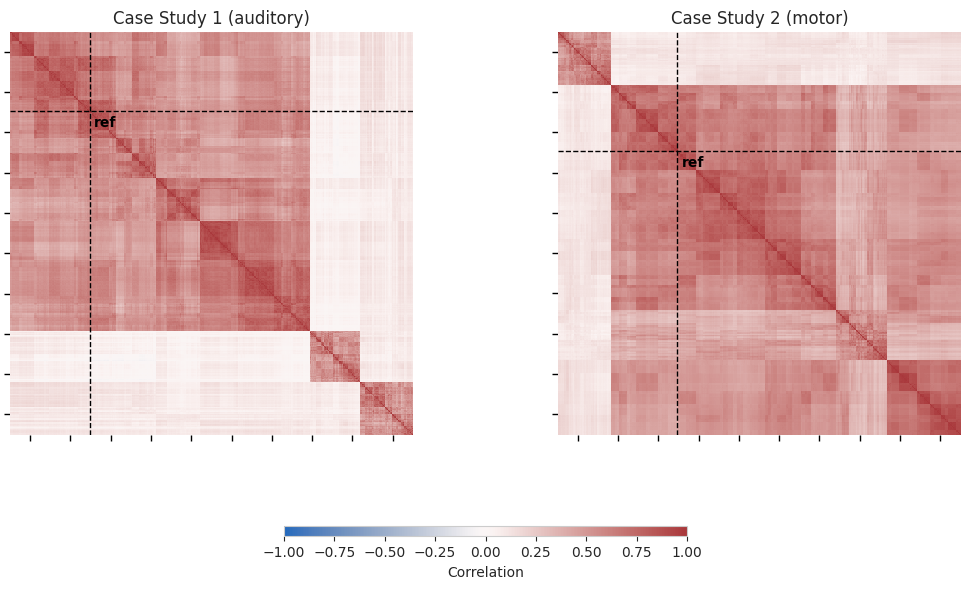

In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import ward, leaves_list
from matplotlib.colors import LinearSegmentedColormap

# Define colormap
# cmap = LinearSegmentedColormap.from_list("red_cmap", ["#FFCCCC", "#FF0000"])
cmap = 'vlag'

def load_and_process(datadir, corr_column=corr):
    ds_path = os.path.join(datadir, 'normalized_dataset.csv')
    corr_path = os.path.join(datadir, 'correlations.csv')
    dataset = pd.read_csv(ds_path, delimiter=';')
    correlations = pd.read_csv(corr_path, delimiter=';')
    matrix = correlations.pivot(index='source', columns='target', values=corr_column).fillna(1.0)

    # Compute distance matrix (1 - correlation)
    distance_matrix = 1 - matrix.values
    np.fill_diagonal(distance_matrix, 0)  # Ensure diagonal is zero

    # Use Ward's method for linkage
    ward_linkage = ward(distance_matrix)

    # Get the order of leaves (items) after clustering
    sorted_index = leaves_list(ward_linkage)
    sorted_ids = matrix.index[sorted_index]

    # Reorder the matrix
    matrix = matrix.reindex(index=sorted_ids, columns=sorted_ids)
    return matrix, dataset, sorted_ids

# Load data
matrix_1, ds_1, sorted_ids_1 = load_and_process(os.path.join('..', 'data', 'case_study_1_revised', ), corr)
matrix_2, ds_2, sorted_ids_2 = load_and_process(os.path.join('..', 'data', 'case_study_2_revised'), corr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Plot heatmaps
sns.heatmap(matrix_1, ax=ax1, cbar=False, cmap=cmap, square=True, vmin=-1, vmax=1)
sns.heatmap(matrix_2, ax=ax2, cbar=False, cmap=cmap, square=True, vmin=-1, vmax=1)

def set_axis_ticks(ax, matrix):
    n = len(matrix)
    step = max(1, n // 10)  # One tick every 100 configs (10 ticks total)
    ticks = np.arange(step // 2, n, step)

    # Set ticks
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    # Remove tick labels
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Ensure ticks are visible
    ax.tick_params(
        axis='both',
        which='both',
        bottom=True,
        top=False,
        left=True,
        right=False,
        labelbottom=False,
        labelleft=False,
        length=4,
        width=1,
        colors='black'
    )

# Apply custom ticks
set_axis_ticks(ax1, matrix_1)
set_axis_ticks(ax2, matrix_2)

# Find the index of 'ref' in the sorted IDs
ref_index_1 = np.where(sorted_ids_1 == 'ref')[0][0]
ref_index_2 = np.where(sorted_ids_2 == 'ref')[0][0]

# Draw crossing lines at 'ref' position for both heatmaps
ax1.axvline(x=ref_index_1, color='black', linestyle='--', linewidth=1.0)
ax1.axhline(y=ref_index_1, color='black', linestyle='--', linewidth=1.0)
ax2.axvline(x=ref_index_2, color='black', linestyle='--', linewidth=1.0)
ax2.axhline(y=ref_index_2, color='black', linestyle='--', linewidth=1.0)

# Add 'ref' label slightly bottom-right of the intersection
offset = 10  # Adjust this value to move the label further away from the cross
ax1.text(ref_index_1 + offset, ref_index_1 + offset, 'ref',
         ha='left', va='top', color='black', fontsize=10, fontweight='bold')
ax2.text(ref_index_2 + offset, ref_index_2 + offset, 'ref',
         ha='left', va='top', color='black', fontsize=10, fontweight='bold')

# Remove x and y axis labels
ax1.set_xlabel('')
ax1.set_ylabel('')
ax2.set_xlabel('')
ax2.set_ylabel('')

# Spacing and Colorbar
plt.subplots_adjust(wspace=0.02, bottom=0.25)
cbar = fig.colorbar(ax1.collections[0], ax=[ax1, ax2], location='bottom', fraction=0.02, pad=0.18, aspect=40)
cbar.set_label('Correlation')

ax1.set_title('Case Study 1 (auditory)')
ax2.set_title('Case Study 2 (motor)')
plt.savefig('correlations_heatmap.png', format='png', bbox_inches='tight', dpi=300)
plt.show()


# Distributions of correlations

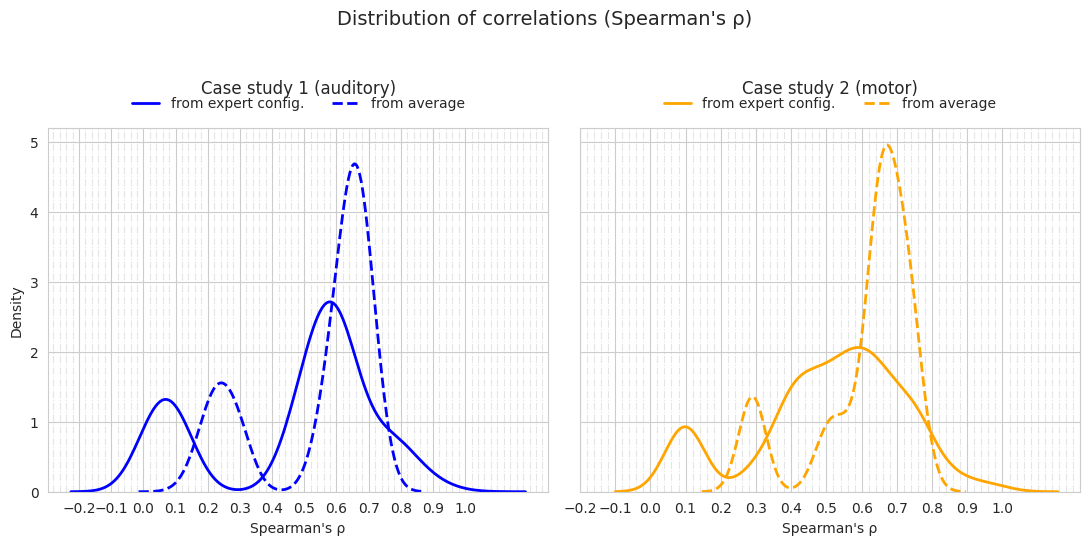

In [12]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load the CSV for data_dir_1
df1 = pd.read_csv(os.path.join(data_dir_1, "correlations.csv"), sep=";")
df1 = df1[df1["source"] != df1["target"]]  # Exclude self-correlations
df1 = df1[df1["source"] < df1["target"]]  # Exclude reverse pairs

# Load the CSV for data_dir_2
df2 = pd.read_csv(os.path.join(data_dir_2, "correlations.csv"), sep=";")
df2 = df2[df2["source"] != df2["target"]]  # Exclude self-correlations
df2 = df2[df2["source"] < df2["target"]]  # Exclude reverse pairs

normalized_df_1 = pd.read_csv(
    os.path.join(data_dir_1, "normalized_dataset.csv"), sep=";"
)
normalized_df_2 = pd.read_csv(
    os.path.join(data_dir_2, "normalized_dataset.csv"), sep=";"
)

# Create a figure with 1 row and 2 columns side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.2), sharey=True)

# ----------------------------------------------------
# Case Study 1 (Left Subplot)
# ----------------------------------------------------
ref_df1 = df1[df1["target"] == "ref"][corr]
sns.kdeplot(
    ref_df1,
    ax=ax1,
    color="blue",
    linewidth=2,
    label="from expert config.",
)
sns.kdeplot(
    normalized_df_1["spearman_from_mean"],
    ax=ax1,
    color="blue",
    linestyle="--",
    linewidth=2,
    label="from average",
)

ax1.set_title("Case study 1 (auditory)", pad=25)
ax1.set_xlabel("Spearman's ρ")
ax1.set_ylabel("Density")
ax1.set_xticks(np.arange(-0.2, 1.1, 0.1))
ax1.minorticks_on()
ax1.grid(True, linestyle="-.", alpha=0.5, which="minor", axis="x")
ax1.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False,
)

# ----------------------------------------------------
# Case Study 2 (Right Subplot)
# ----------------------------------------------------
ref_df2 = df2[df2["target"] == "ref"]["spearman"]
sns.kdeplot(
    ref_df2,
    ax=ax2,
    color="orange",
    linewidth=2,
    label="from expert config.",
)
sns.kdeplot(
    normalized_df_2["spearman_from_mean"],
    ax=ax2,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="from average",
)

ax2.set_title("Case study 2 (motor)", pad=25)
ax2.set_xlabel("Spearman's ρ")
ax2.set_ylabel("Density")
ax2.set_xticks(np.arange(-0.2, 1.1, 0.1))
ax2.minorticks_on()
ax2.grid(True, linestyle="-.", alpha=0.5, which="minor", axis="x")
ax2.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False,
)

# Final layout adjustments
plt.suptitle("Distribution of correlations (Spearman's ρ)", y=1.04, fontsize=14)
plt.tight_layout()

# Save figures
plt.savefig("correlations_distribution.svg", format="svg", bbox_inches="tight")
plt.savefig("correlations_distribution.png", format="png", bbox_inches="tight")
plt.show()

1001 configs in dataset
1002001 correlations in matrix


/home/ymerel/fmri/sosym_2026/.venv/lib64/python3.13/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 2000x2000 with 0 Axes>

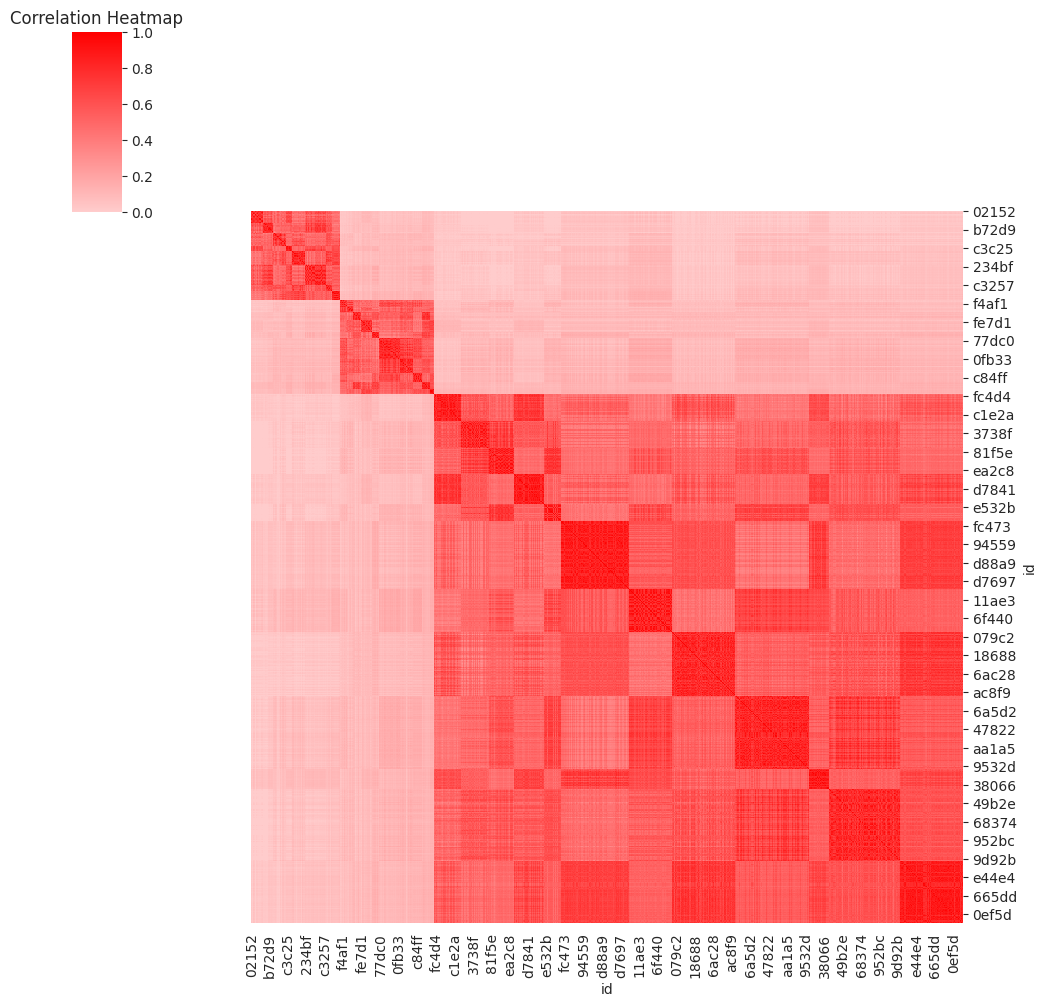

In [29]:
from utils import clusterize_hierch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

datadir = os.path.join('..', 'data', 'case_study_1_revised',)
ds_path = os.path.join(datadir, 'normalized_dataset.csv')
corr_path = os.path.join(datadir, 'correlations.csv')

plt.figure(figsize=(20, 20))
cmap = LinearSegmentedColormap.from_list("red_cmap", ["#FFCCCC", "#FF0000"])

threshold = 0.20

dataset = pd.read_csv(ds_path, delimiter=';')

print(f"{len(dataset)} configs in dataset")

correlations = pd.read_csv(corr_path, delimiter=';')
print(f"{len(correlations)} correlations in matrix")

matrix = correlations.pivot(index='source', columns='target', values=corr).fillna(1.0)

ds, distance_matrix, Z, clusters = clusterize_hierch(dataset, correlations, dataset['id'], None, corr, threshold)

# reorder matrix by cluster
sorted_index = ds.sort_values('cluster', ascending=False)['id']
matrix = matrix.reindex(index=sorted_index, columns=sorted_index)
matrix.index = matrix.index.str.slice(0, 5)
matrix.columns = matrix.columns.str.slice(0, 5)
map = sns.clustermap(matrix, cmap=cmap, vmin=0, vmax=1, row_cluster=False, col_cluster=False, row_linkage=Z, col_linkage=Z, square=True)
plt.title('Correlation Heatmap')
plt.show()

1001 configs in dataset
1004004 correlations in matrix


<Figure size 2000x2000 with 0 Axes>

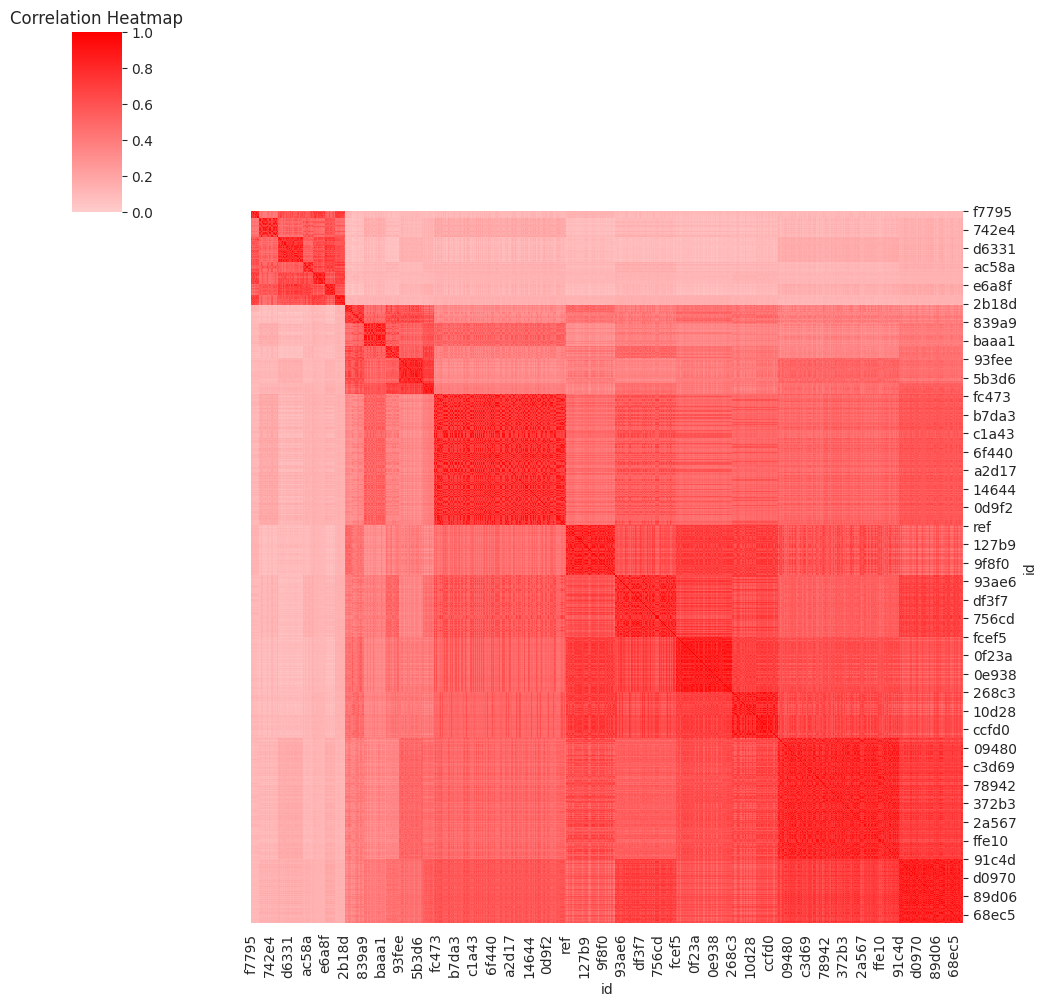

In [30]:
from utils import clusterize_hierch
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

datadir = os.path.join('..', 'data', 'case_study_2_revised')
ds_path = os.path.join(datadir, 'normalized_dataset.csv')
corr_path = os.path.join(datadir, 'correlations.csv')

plt.figure(figsize=(20, 20))
cmap = LinearSegmentedColormap.from_list("red_cmap", ["#FFCCCC", "#FF0000"])

threshold = 0.20

dataset = pd.read_csv(ds_path, delimiter=';')

print(f"{len(dataset)} configs in dataset")

correlations = pd.read_csv(corr_path, delimiter=';')
print(f"{len(correlations)} correlations in matrix")

matrix = correlations.pivot(index='source', columns='target', values='spearman').fillna(1.0)

ds, distance_matrix, Z, clusters = clusterize_hierch(dataset, correlations, dataset['id'], None, 'spearman', threshold)

# reorder matrix by cluster
sorted_index = ds.sort_values('cluster', ascending=False)['id']
matrix = matrix.reindex(index=sorted_index, columns=sorted_index)
matrix.index = matrix.index.str.slice(0, 5)
matrix.columns = matrix.columns.str.slice(0, 5)
map = sns.clustermap(matrix, cmap=cmap, vmin=0, vmax=1, row_cluster=False, col_cluster=False, row_linkage=Z, col_linkage=Z)
plt.title('Correlation Heatmap')
plt.show()